<a href="https://colab.research.google.com/github/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/blob/main/Lab%2014/%5BLab_14%5D_Diagnostics_%E2%80%94_When_OLS_Fails.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Ingestion and Naive Baseline Model
url = 'https://raw.githubusercontent.com/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/refs/heads/main/Data/Nvidia_AI_Capex_Diagnostics_2026.csv'
df = pd.read_csv(url)

formula = 'AI_Software_Revenue ~ Hardware_Capex + Data_Center_Power_MW + Cloud_GPU_Deployments'
baseline_model = smf.ols(formula, data=df).fit()

print("--- NAIVE BASELINE OLS MODEL ---")
print(baseline_model.summary())

--- NAIVE BASELINE OLS MODEL ---
                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     2831.
Date:                 Mon, 23 Mar 2026   Prob (F-statistic):          2.35e-190
Time:                         19:52:35   Log-Likelihood:                -1409.7
No. Observations:                  250   AIC:                             2827.
Df Residuals:                      246   BIC:                             2841.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

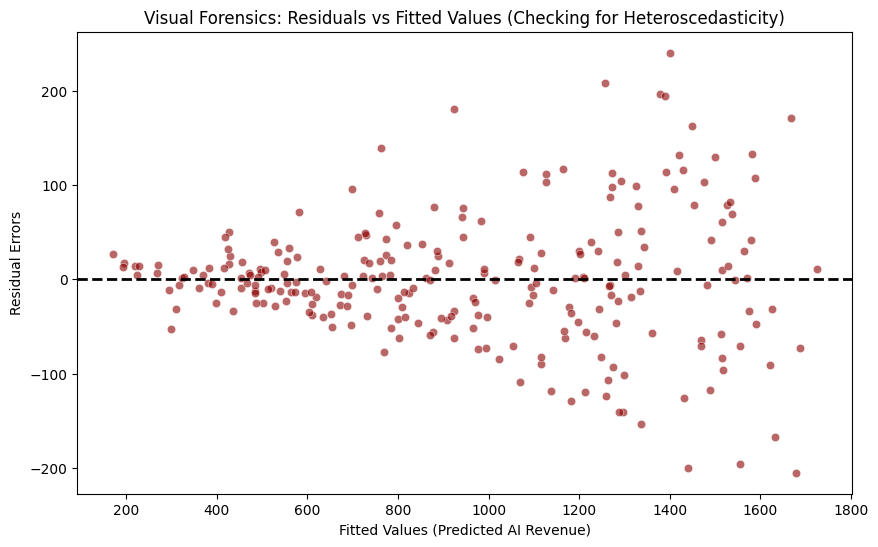

In [5]:
# Step 2: Visual Forensics
fitted_vals = baseline_model.fittedvalues
residuals = baseline_model.resid

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals, alpha=0.6, color='darkred')
plt.axhline(0, color='black', linestyle='--', linewidth=2)
plt.title('Visual Forensics: Residuals vs Fitted Values (Checking for Heteroscedasticity)')
plt.xlabel('Fitted Values (Predicted AI Revenue)')
plt.ylabel('Residual Errors')
plt.show()

In [6]:
# Step 3: The White Test Execution
# We must extract the design matrix generated by the formula interface
exog_matrix = baseline_model.model.exog
white_test_results = het_white(baseline_model.resid, exog_matrix)

labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print("\n--- WHITE TEST RESULTS ---")
print(dict(zip(labels, [f"{x:.2f}" for x in white_test_results])))


--- WHITE TEST RESULTS ---
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}


In [9]:
# Step 4: Variance Inflation Factor (VIF) Loop
print("\n--- VARIANCE INFLATION FACTORS ---")

# Start loop at 1 to skip the constant intercept column at index 0
for i in range(1, exog_matrix.shape[1]):
    vif = variance_inflation_factor(exog_matrix, i)
    print(dict(zip(labels, [f"{x:.2f}" for x in white_test_results])))


--- VARIANCE INFLATION FACTORS ---
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}
{'LM Statistic': '57.28', 'LM-Test p-value': '0.00', 'F-Statistic': '7.93', 'F-Test p-value': '0.00'}


In [11]:
# Step 5: The Correction - HC3 Robust Standard Errors
robust_model = smf.ols(formula, data=df).fit(cov_type='HC3')
print(robust_model.summary())

print("\n--- ROBUST OLS MODEL (HC3) ---")
print(robust_model.summary())

                             OLS Regression Results                            
Dep. Variable:     AI_Software_Revenue   R-squared:                       0.972
Model:                             OLS   Adj. R-squared:                  0.972
Method:                  Least Squares   F-statistic:                     2375.
Date:                 Mon, 23 Mar 2026   Prob (F-statistic):          2.91e-181
Time:                         20:12:47   Log-Likelihood:                -1409.7
No. Observations:                  250   AIC:                             2827.
Df Residuals:                      246   BIC:                             2841.
Df Model:                            3                                         
Covariance Type:                   HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept           

 AI-Assisted Expansion

In [14]:
# Install Streamlit (required to run this app)
!pip install streamlit

"""
Interactive OLS Diagnostic Dashboard
Built with Streamlit + Plotly for the Lab 14 expansion task.

HOW TO RUN LOCALLY:
    1. Install dependencies:
       pip install streamlit plotly pandas statsmodels
    2. Launch the app:
       streamlit run diagnostic_dashboard.py
    3. A browser tab opens automatically at http://localhost:8501
"""

import streamlit as st          # st.* calls add UI elements to the page
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# ── PAGE CONFIG ──────────────────────────────────────────────────────────────
# Must be the very first Streamlit call in the script.
st.set_page_config(
    page_title="OLS Diagnostic Dashboard",
    page_icon="📊",
    layout="wide"   # "wide" uses the full browser width instead of centering a narrow column
)

# ── DATA & MODEL LOADING (CACHED) ────────────────────────────────────────────
# @st.cache_data tells Streamlit to run this function ONCE and store the result
# in memory. On every subsequent re-run (e.g., user toggles a widget) Streamlit
# returns the cached value instantly instead of re-downloading and refitting.
@st.cache_data
def load_data():
    url = (
        "https://raw.githubusercontent.com/zzzzzssyy/ECON3916-33674-Statistical-"
        "Machine-Learning/refs/heads/main/Data/Nvidia_AI_Capex_Diagnostics_2026.csv"
    )
    return pd.read_csv(url)


@st.cache_data
def fit_models(csv_url: str):
    """
    Fit the naive OLS and robust HC3 models.
    Accepts the URL string as an argument so Streamlit can hash it for the
    cache key — cache_data requires all arguments to be hashable.
    """
    df = pd.read_csv(csv_url)
    formula = "AI_Software_Revenue ~ Hardware_Capex + Data_Center_Power_MW + Cloud_GPU_Deployments"

    naive   = smf.ols(formula, data=df).fit()                    # plain OLS
    robust  = smf.ols(formula, data=df).fit(cov_type="HC3")      # heteroscedasticity-robust SEs

    exog    = naive.model.exog                                    # design matrix (N × k)
    white   = het_white(naive.resid, exog)                        # White test on the naive model

    # VIF: skip column 0 (the intercept) — VIF is undefined for the constant
    vif_scores = {
        naive.model.exog_names[i]: variance_inflation_factor(exog, i)
        for i in range(1, exog.shape[1])
    }

    return df, naive, robust, white, vif_scores


# ── LOAD EVERYTHING ──────────────────────────────────────────────────────────
DATA_URL = (
    "https://raw.githubusercontent.com/zzzzzssyy/ECON3916-33674-Statistical-"
    "Machine-Learning/refs/heads/main/Data/Nvidia_AI_Capex_Diagnostics_2026.csv"
)

with st.spinner("Loading data and fitting models…"):
    df, naive_model, robust_model, white_results, vif_scores = fit_models(DATA_URL)

# ── HEADER ───────────────────────────────────────────────────────────────────
st.title("📊 OLS Diagnostic Dashboard")
st.markdown(
    "**Lab 14 · Diagnostics: When OLS Fails** — "
    "Explore heteroscedasticity, multicollinearity, and the impact of robust corrections."
)
st.divider()

# ── LAYOUT: TWO COLUMNS FOR TOP SECTION ──────────────────────────────────────
# st.columns() returns a list of column objects; use them as context managers
# (with col:) or directly assign widgets to col.widget().
col_left, col_right = st.columns([1, 1], gap="large")

# ── LEFT COLUMN: MODEL SUMMARY TOGGLE ────────────────────────────────────────
with col_left:
    st.subheader("📋 Regression Summary")

    # st.radio() renders a set of mutually exclusive buttons.
    # The return value is the currently selected label string.
    model_choice = st.radio(
        "Select model",
        options=["Naive OLS", "Robust HC3"],
        horizontal=True,         # render buttons side-by-side rather than stacked
        help="Toggle between the standard OLS summary and the heteroscedasticity-robust HC3 version."
    )

    # Display the statsmodels summary as pre-formatted text inside a scrollable box.
    selected_model = naive_model if model_choice == "Naive OLS" else robust_model
    st.code(str(selected_model.summary()), language=None)

    # Plain-English interpretation hint
    if model_choice == "Naive OLS":
        st.info(
            "⚠️ **Naive OLS** assumes constant error variance (homoscedasticity). "
            "If that assumption is violated, the standard errors—and therefore p-values—are unreliable."
        )
    else:
        st.success(
            "✅ **Robust HC3** corrects the standard errors for heteroscedasticity without "
            "changing the point estimates. Compare coefficient significance with the Naive OLS tab."
        )

# ── RIGHT COLUMN: RESIDUAL SCATTER ───────────────────────────────────────────
with col_right:
    st.subheader("🔍 Residuals vs. Fitted Values")

    # Build an interactive Plotly scatter plot.
    # Plotly Express would be one line, but go.Figure gives finer control.
    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=naive_model.fittedvalues,
            y=naive_model.resid,
            mode="markers",
            marker=dict(color="darkred", opacity=0.6, size=7),
            name="Residuals",
            hovertemplate="Fitted: %{x:,.0f}<br>Residual: %{y:,.0f}<extra></extra>"
        )
    )

    # Reference line at y = 0
    fig.add_hline(
        y=0,
        line_dash="dash",
        line_color="black",
        line_width=2,
        annotation_text="Zero line",
        annotation_position="top right"
    )

    fig.update_layout(
        xaxis_title="Fitted Values (Predicted AI Revenue)",
        yaxis_title="Residual Errors",
        height=420,
        margin=dict(l=40, r=20, t=30, b=40),
        hovermode="closest"
    )

    # st.plotly_chart renders the Plotly figure inline.
    # use_container_width=True makes it fill the column instead of using a fixed pixel width.
    st.plotly_chart(fig, use_container_width=True)

    # Visual interpretation hint
    st.markdown(
        "**How to read this chart:** A random scatter around zero suggests homoscedasticity. "
        "A fan-shaped or funnel pattern (residuals growing with fitted values) is the classic "
        "signature of **heteroscedasticity**."
    )

st.divider()

# ── WHITE TEST RESULTS ────────────────────────────────────────────────────────
st.subheader("🧪 White Test for Heteroscedasticity")

# Unpack the four numbers returned by het_white()
lm_stat, lm_pval, f_stat, f_pval = white_results

# st.columns() again — four equal-width metric cards
m1, m2, m3, m4 = st.columns(4)

# st.metric() displays a labelled number prominently (like a KPI card)
m1.metric("LM Statistic",    f"{lm_stat:.4f}")
m2.metric("LM p-value",      f"{lm_pval:.4f}", delta="⚠️ Reject H₀" if lm_pval < 0.05 else "✅ Fail to Reject")
m3.metric("F Statistic",     f"{f_stat:.4f}")
m4.metric("F p-value",       f"{f_pval:.4f}", delta="⚠️ Reject H₀" if f_pval < 0.05 else "✅ Fail to Reject")

# Interpretation blurb
if lm_pval < 0.05:
    st.warning(
        "**White Test conclusion:** p < 0.05 → reject the null of homoscedasticity. "
        "Heteroscedasticity is present. Use the HC3 robust model to obtain valid inference."
    )
else:
    st.success(
        "**White Test conclusion:** p ≥ 0.05 → fail to reject the null. "
        "No strong evidence of heteroscedasticity."
    )

st.divider()

# ── VIF SCORES ────────────────────────────────────────────────────────────────
st.subheader("📐 Variance Inflation Factors (VIF)")

# Explanatory copy before the chart
st.markdown(
    "VIF measures how much the variance of an estimated coefficient is inflated due to "
    "multicollinearity with the other predictors. "
    "Rule of thumb: **VIF > 5 → moderate concern**, **VIF > 10 → severe**."
)

# Build a tidy DataFrame for display and charting
vif_df = pd.DataFrame(
    {"Predictor": list(vif_scores.keys()), "VIF": list(vif_scores.values())}
).sort_values("VIF", ascending=False)

# Colour-encode bars: green < 5, amber 5-10, red > 10
def vif_colour(v):
    if v < 5:
        return "#2ecc71"
    elif v < 10:
        return "#f39c12"
    return "#e74c3c"

bar_colours = [vif_colour(v) for v in vif_df["VIF"]]

fig_vif = go.Figure(
    go.Bar(
        x=vif_df["Predictor"],
        y=vif_df["VIF"],
        marker_color=bar_colours,
        text=[f"{v:.2f}" for v in vif_df["VIF"]],
        textposition="outside",
        hovertemplate="%{x}: VIF = %{y:.2f}<extra></extra>"
    )
)

# Add threshold reference lines
fig_vif.add_hline(y=5,  line_dash="dot",  line_color="#f39c12", annotation_text="VIF = 5  (moderate)",  annotation_position="top right")
fig_vif.add_hline(y=10, line_dash="dash", line_color="#e74c3c",  annotation_text="VIF = 10 (severe)",    annotation_position="top right")

fig_vif.update_layout(
    yaxis_title="VIF Score",
    xaxis_title="Predictor Variable",
    height=380,
    margin=dict(l=40, r=20, t=30, b=60),
    showlegend=False
)

# Two-column layout: chart left, table right
col_chart, col_table = st.columns([2, 1], gap="large")

with col_chart:
    st.plotly_chart(fig_vif, use_container_width=True)

with col_table:
    st.markdown("**VIF Table**")
    # style the DataFrame: highlight high-VIF rows in red
    def highlight_vif(row):
        colour = vif_colour(row["VIF"])
        return [f"background-color: {colour}22; color: {'#c0392b' if colour == '#e74c3c' else 'inherit'}" for _ in row]

    st.dataframe(
        vif_df.style.apply(highlight_vif, axis=1).format({"VIF": "{:.2f}"}),
        use_container_width=True,
        hide_index=True
    )

st.divider()

# ── FOOTER / HOW TO INTERPRET ─────────────────────────────────────────────────
with st.expander("📖 How to Interpret These Visualizations", expanded=False):
    st.markdown(
        """
### Residuals vs. Fitted Values
Hover over any point to see its exact fitted value and residual.
- **Random cloud** → errors are well-behaved (homoscedastic).
- **Fan or funnel shape** → variance of errors grows with fitted values → heteroscedasticity.

### White Test
The null hypothesis (H₀) is homoscedasticity.
- **p < 0.05** → reject H₀; heteroscedasticity is statistically significant.
- In practice, always pair the formal test with the visual above.

### Naive OLS vs. Robust HC3
Toggle the radio button to compare the two model summaries side-by-side:
- **Point estimates (coefficients)** are identical — HC3 does *not* change the fitted line.
- **Standard errors** will differ when heteroscedasticity is present, causing **t-statistics and p-values** to change.
- If a variable is significant in Naive OLS but not in HC3, the naive significance was inflated by heteroscedasticity.

### VIF Scores
- **VIF = 1** → no collinearity at all.
- **1 < VIF < 5** → acceptable.
- **5 ≤ VIF < 10** → moderate; consider centering, PCA, or dropping a predictor.
- **VIF ≥ 10** → severe; coefficient estimates are unstable.
"""
    )

st.caption("Lab 14 · ECON 3916 · Diagnostic Dashboard · Built with Streamlit & Plotly")

ERROR: Operation cancelled by user


2026-03-23 20:17:08.542 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:17:08.544 No runtime found, using MemoryCacheStorageManager
2026-03-23 20:17:08.545 No runtime found, using MemoryCacheStorageManager
2026-03-23 20:17:08.548 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:17:08.569 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:17:08.570 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:17:08.572 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:17:08.574 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-23 20:17:08.576 Thread 'MainThread': missing ScriptRunContext! This warning can be ignor

DeltaGenerator()